In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
from pathlib import Path 
 
ROOT=Path.cwd().parent
df=pd.read_csv(ROOT/'data'/'processed'/'hospital_clean.csv')

print(f'Shape: {df.shape}')
print(df.dtypes)
print(df.isnull().sum().sort_values(ascending=False).head(20))

print('\nReadmission distribution:')
print(df['readmitted'].value_counts())
print(df['readmitted'].value_counts(normalize=True).round(3)*100)

Shape: (99493, 53)
encounter_id                 int64
patient_nbr                  int64
race                        object
gender                      object
age                         object
admission_type_id            int64
discharge_disposition_id     int64
admission_source_id          int64
time_in_hospital             int64
num_lab_procedures           int64
num_procedures               int64
num_medications              int64
number_outpatient            int64
number_emergency             int64
number_inpatient             int64
diag_1                      object
diag_2                      object
diag_3                      object
number_diagnoses             int64
max_glu_serum               object
A1Cresult                   object
metformin                   object
repaglinide                 object
nateglinide                 object
chlorpropamide              object
glimepiride                 object
acetohexamide               object
glipizide                   object
g

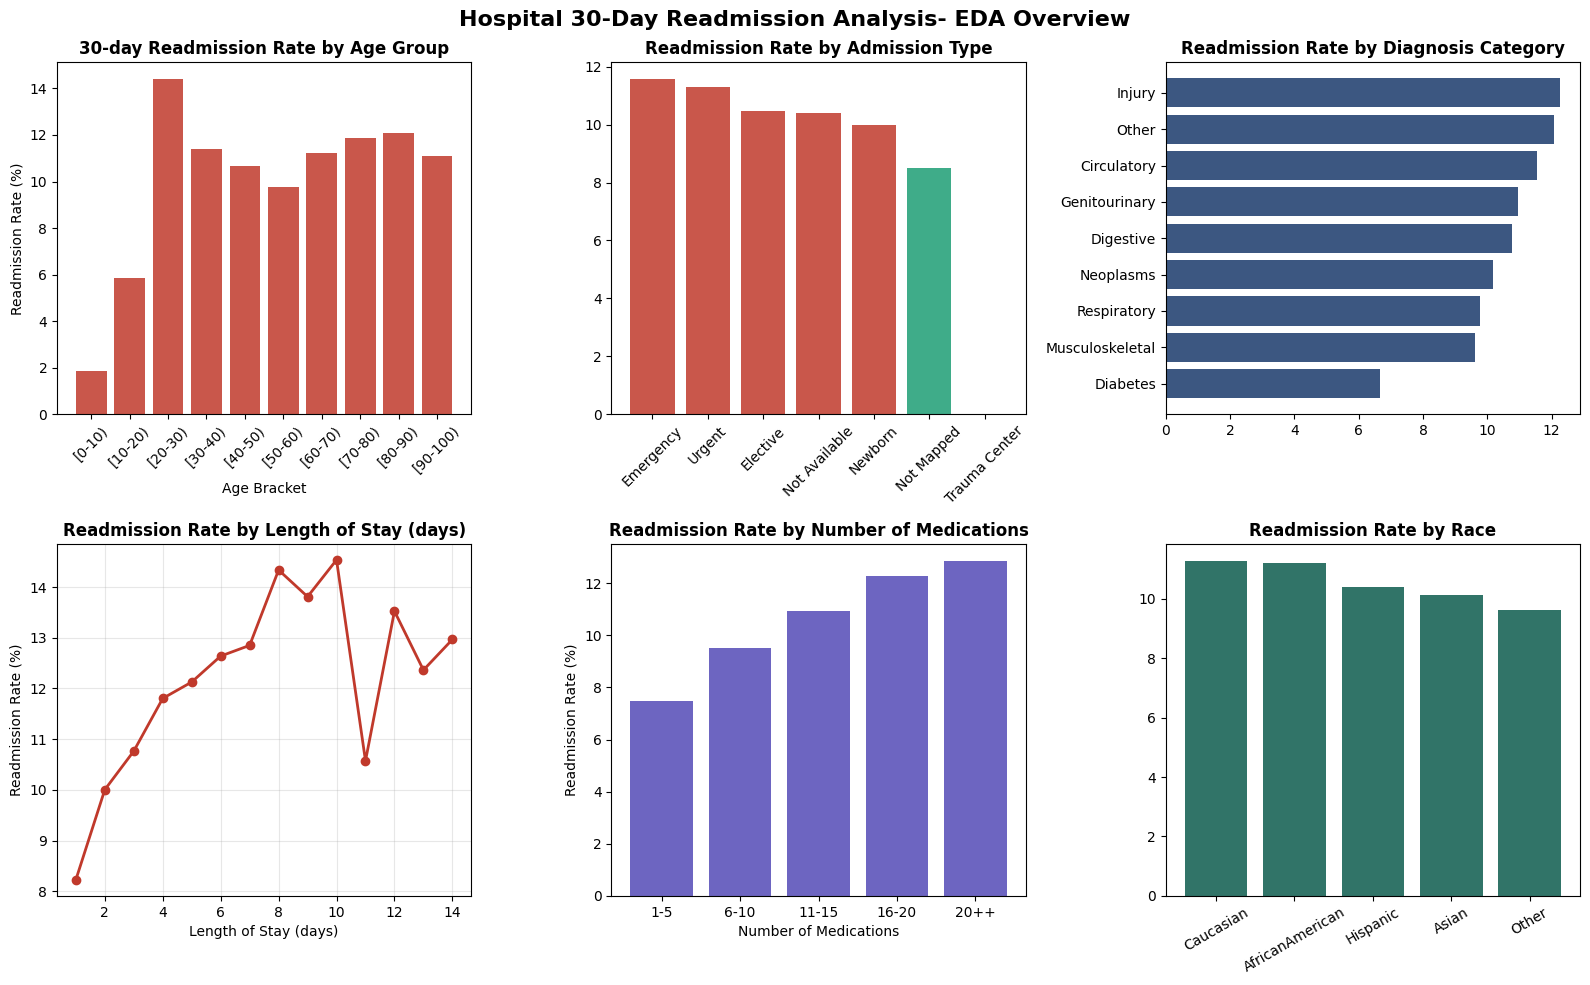

In [19]:
fig,axes=plt.subplots(2,3,figsize=(16,10))

#Age group
readm_age=df.groupby('age')['readmitted_30'].mean()*100
axes[0,0].bar(readm_age.index,readm_age.values,color='#C0392B',alpha=0.85)
axes[0,0].set_title('30-day Readmission Rate by Age Group', fontweight='bold')
axes[0,0].set_xlabel('Age Bracket')
axes[0,0].set_ylabel('Readmission Rate (%)')
axes[0,0].tick_params(axis='x',rotation=45)


#Admission Type
readm_adm=df.groupby('admission_type')['readmitted_30'].mean()*100
readm_adm=readm_adm.sort_values(ascending=False)
colors = ['#C0392B' if v > readm_adm.mean() else '#1D9E75' for v in readm_adm.values]
axes[0,1].bar(readm_adm.index,readm_adm.values,color=colors,alpha=0.85)
axes[0,1].set_title('Readmission Rate by Admission Type',fontweight='bold')
axes[0,1].tick_params(axis='x',rotation=45)

#Diagnosis Category
readm_diag=df.groupby('diag_category')['readmitted_30'].mean()*100
readm_diag=readm_diag.sort_values(ascending=False)
axes[0,2].barh(readm_diag.index[::-1],readm_diag.values[::-1],color='#1A3A6B',alpha=0.85)
axes[0,2].set_title('Readmission Rate by Diagnosis Category',fontweight='bold')

#Length of stay vs readmission
los_readm=df.groupby('time_in_hospital')['readmitted_30'].mean()*100
axes[1,0].plot(los_readm.index,los_readm.values,marker='o',color='#C0392B',linewidth=2)
axes[1,0].set_title('Readmission Rate by Length of Stay (days)',fontweight='bold')
axes[1,0].set_xlabel('Length of Stay (days)')
axes[1,0].set_ylabel('Readmission Rate (%)')
axes[1,0].grid(True,alpha=0.3)

#Number of medications vs readmission
df['med_group']=pd.cut(df['num_medications'],bins=[0,5,10,15,20,80],labels=['1-5','6-10','11-15','16-20','20++'])
readm_med=df.groupby('med_group',observed=True)['readmitted_30'].mean()*100
axes[1,1].bar(readm_med.index,readm_med.values,color='#534AB7',alpha=0.85)
axes[1,1].set_title('Readmission Rate by Number of Medications',fontweight='bold')
axes[1,1].set_xlabel('Number of Medications')
axes[1,1].set_ylabel('Readmission Rate (%)')


#Race
readm_race=df.groupby('race')['readmitted_30'].mean()*100
readm_race=readm_race.sort_values(ascending=False)
axes[1,2].bar(readm_race.index,readm_race.values,color='#0D5C4E',alpha=0.85)
axes[1,2].set_title('Readmission Rate by Race',fontweight='bold')
axes[1,2].tick_params(axis='x',rotation=30)


plt.suptitle('Hospital 30-Day Readmission Analysis- EDA Overview', fontsize=16,fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/eda_overview.png',dpi=150,bbox_inches='tight')
plt.show()

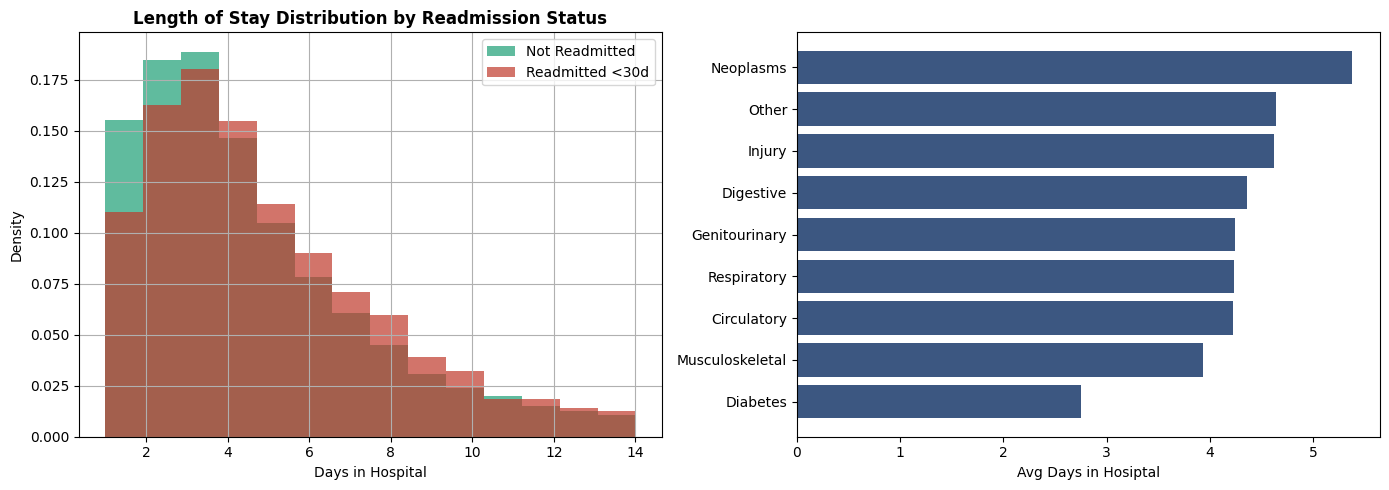

LOS mean (readmitted): 4.77 days
LOS mean (not readmitted): 4.35 days
T-test p-value: 0.000000
Statistically significant difference


In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# LOS distribution for readmitted vs not
df[df['readmitted_30']==0]['time_in_hospital'].hist(
    ax=axes[0], bins=14, alpha=0.7, color='#1D9E75', label='Not Readmitted', density=True)
df[df['readmitted_30']==1]['time_in_hospital'].hist(
    ax=axes[0], bins=14, alpha=0.7, color='#C0392B', label='Readmitted <30d', density=True)
axes[0].set_title('Length of Stay Distribution by Readmission Status', fontweight='bold')
axes[0].set_xlabel('Days in Hospital')
axes[0].set_ylabel('Density')
axes[0].legend()

avg_los=df.groupby('diag_category')['time_in_hospital'].mean().sort_values(ascending=False)
axes[1].barh(avg_los.index[::-1],avg_los.values[::-1],color='#1A3A6B',alpha=0.85)
axes[1].set_xlabel('Avg Days in Hosiptal')

plt.tight_layout()
plt.savefig('../reports/figures/los_analysis.png',dpi=150,bbox_inches='tight')
plt.show()

from scipy import stats
los_readmitted=df[df['readmitted_30']==1]['time_in_hospital']
los_not=df[df['readmitted_30']==0]['time_in_hospital']
t_stat,p_value=stats.ttest_ind(los_readmitted,los_not)
print(f'LOS mean (readmitted): {los_readmitted.mean():.2f} days')
print(f'LOS mean (not readmitted): {los_not.mean():.2f} days')

print(f'T-test p-value: {p_value:.6f}')
print('Statistically significant difference' if p_value<0.05 else 'No Significant difference')